In [ ]:
import numpy as np
import pandas as pd
import pymc as pm
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist

np.random.seed(42)
df = pd.read_parquet("../../data/benchmark/testing/eth")
scaler = StandardScaler()

df = df.select_dtypes(include=[np.number]).dropna()
df = df.sample(300)

data = df.to_numpy().flatten()

with pm.Model() as model:
    num_clusters = 2

    cluster_means = pm.Normal("cluster_means", mu=0, sigma=5, shape=num_clusters)
    cluster_std = pm.HalfNormal("cluster_std", sigma=2, shape=num_clusters)

    cluster_weights = pm.Dirichlet(
        "cluster_weights", a=np.ones(num_clusters) * 10
    )

    weighted_likelihoods = []
    for k in range(num_clusters):
        likelihood_k = (
            -0.5
            * pm.math.sqr((data[:, None] - cluster_means[k]) / cluster_std[k])
            - pm.math.log(cluster_std[k])
            - 0.5 * pm.math.log(2 * np.pi)
        )
        weighted_likelihoods.append(pm.math.log(cluster_weights[k]) + likelihood_k)

    total_log_likelihood = pm.math.logsumexp(weighted_likelihoods, axis=0)

    pm.Potential("obs", total_log_likelihood.sum())

    approx = pm.fit(n=100, method="advi")

trace = approx.sample(20)

posterior_means = trace.posterior["cluster_means"].mean(dim=["chain", "draw"]).values
posterior_stds = trace.posterior["cluster_std"].mean(dim=["chain", "draw"]).values

posterior_weights = (
    trace.posterior["cluster_weights"].mean(dim=["chain", "draw"]).values
)

log_probs = np.array(
    [
        -0.5 * ((data[:, None] - posterior_means[k]) / posterior_stds[k]) ** 2
        - np.log(posterior_stds[k])
        - 0.5 * np.log(2 * np.pi)
        for k in range(num_clusters)
    ]
)

log_probs = log_probs.T + np.log(posterior_weights)
log_probs = log_probs[0]

cluster_assignments = np.argmax(
    log_probs, axis=1
)

distance_matrix = pdist(data.reshape(-1, 1))
linkage_matrix = linkage(distance_matrix, method="ward")

Finished [100%]: Average Loss = 1.2586e+10


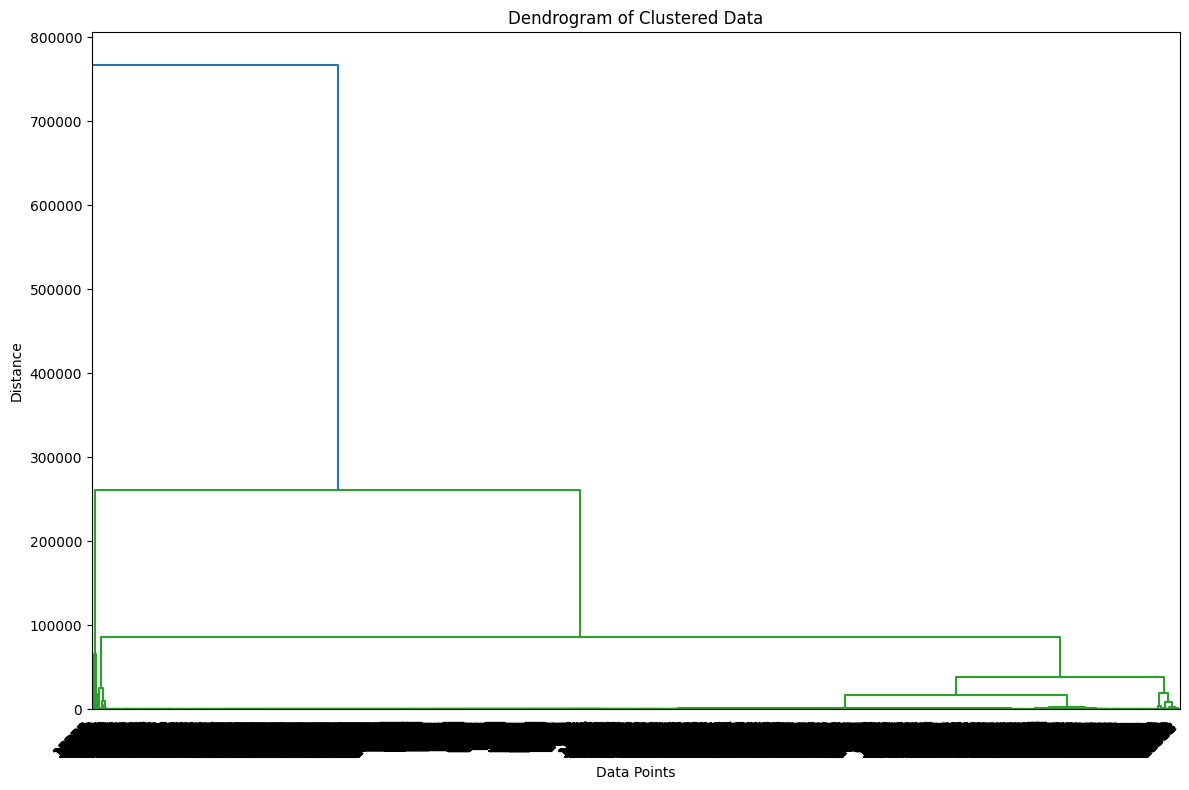

[9.8278608e+00 6.2790698e-01 1.3743547e-01 ... 0.0000000e+00 3.0928104e+02
 2.9858371e+02]
[3 3 3 ... 3 0 0]


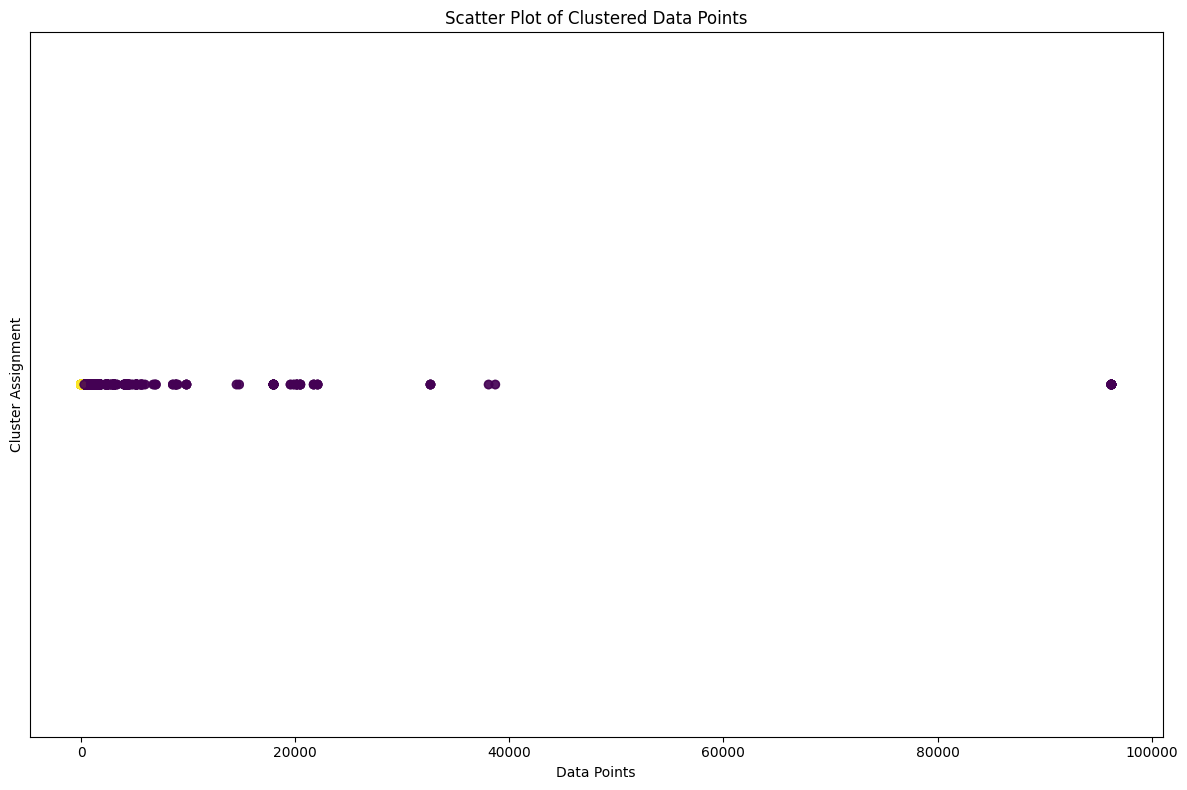

In [6]:
plt.figure(figsize=(12, 8))
dendrogram(
    linkage_matrix, labels=np.arange(len(data)), leaf_rotation=90, leaf_font_size=10
)
plt.title("Dendrogram of Clustered Data")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(data)
print(cluster_assignments)

plt.figure(figsize=(12, 8))

plt.scatter(
    data,
    np.zeros_like(data),
    c=cluster_assignments,
    cmap="viridis",
    marker="o",
    alpha=0.7,
)

plt.title("Scatter Plot of Clustered Data Points")
plt.xlabel("Data Points")
plt.ylabel("Cluster Assignment")
plt.yticks([])
plt.tight_layout()

plt.show()